In [62]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression ,Ridge , Lasso
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error

In [63]:
df = pd.read_csv(r'/home/ahmed/Desktop/datascince/prj /Project Data/student_performance_dirty.csv')

In [64]:
df.head()

,Study_Hours,Attendance,Assignments_Score,Exam_Score,Projects_Score,Major
0,8.548792,6.486562,-0.969794,-8.064920,-5.792677,Engineering
1,3.649343,-6.424186,-1.205661,10.753964,-9.156739,Medicine
2,2.997129,9.721865,-5.093313,-4.030047,7.612123,Engineering
3,11.601232,-1.579187,-1.090158,2.557463,-10.771740,Medicine
4,5.001749,4.658271,-2.899465,-7.090157,4.642939,CS


In [65]:
df.describe()

,Study_Hours,Attendance,Assignments_Score,Exam_Score,Projects_Score
count,195.000000,199.000000,197.000000,197.000000,200.000000
mean,1.153932,2.751694,-3.759669,0.101239,0.548906
std,6.217763,6.628207,4.044197,7.206339,7.734168
min,-13.664127,-14.228711,-13.781812,-15.717262,-15.296002
25%,-2.248278,-2.504055,-6.392132,-5.616049,-6.145499
50%,2.214871,3.546637,-2.901463,-0.000404,-0.034422
75%,5.466463,8.307877,-1.080250,6.065942,7.606014
max,14.053299,16.818421,4.494113,13.592289,16.496410


In [66]:
df.isnull().sum()

Study_Hours          7
Attendance           3
Assignments_Score    5
Exam_Score           5
Projects_Score       2
Major                0
dtype: int64

In [67]:
df.duplicated().sum()

np.int64(12)

In [68]:
df.drop_duplicates(inplace=True)

In [69]:
df.duplicated().sum()

np.int64(0)

In [70]:
df.fillna(df.mean(numeric_only=True), inplace=True)

,Study_Hours,Attendance,Assignments_Score,Exam_Score,Projects_Score,Major
0,8.548792,6.486562,-0.969794,-8.064920,-5.792677,Engineering
1,3.649343,-6.424186,-1.205661,10.753964,-9.156739,Medicine
2,2.997129,9.721865,-5.093313,-4.030047,7.612123,Engineering
3,11.601232,-1.579187,-1.090158,2.557463,-10.771740,Medicine
4,5.001749,4.658271,-2.899465,-7.090157,4.642939,CS
...,...,...,...,...,...,...
185,2.243331,1.189654,-8.964063,1.783730,-0.563321,Medicine
186,6.598650,7.860041,-3.769720,-11.910580,-5.021424,Medicine
187,-4.734741,11.880999,-4.250899,2.076378,7.322405,CS
188,1.151912,8.011362,-1.208342,-6.494767,-4.714916,Engineering


In [71]:
df.isnull().sum()


Study_Hours          0
Attendance           0
Assignments_Score    0
Exam_Score           0
Projects_Score       0
Major                0
dtype: int64

In [72]:
le = LabelEncoder()
df['Major'] = le.fit_transform(df['Major'])

In [73]:
y = df['Exam_Score']
x = df.drop('Exam_Score', axis=1)

In [74]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [75]:
model = LinearRegression()
model.fit(x_train,y_train)

y_pred = model.predict(x_test)

In [76]:
mse= mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)


print("MSE:", mse)
print("RMSE:", rmse)

MSE: 36.73479006824894
RMSE: 6.060923202635795


In [77]:
ridge = Ridge()
ridge.fit(x_train, y_train)

ridge_pred = ridge.predict(x_test)

ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)

print(ridge_mse)
print(ridge_rmse)

36.72885982191379
6.060433963167472


In [78]:
lasso = Lasso()
lasso.fit(x_train, y_train)

lasso_pred = lasso.predict(x_test)

lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)

print(lasso_mse)
print(lasso_rmse)

35.47340313655945
5.95595526650087


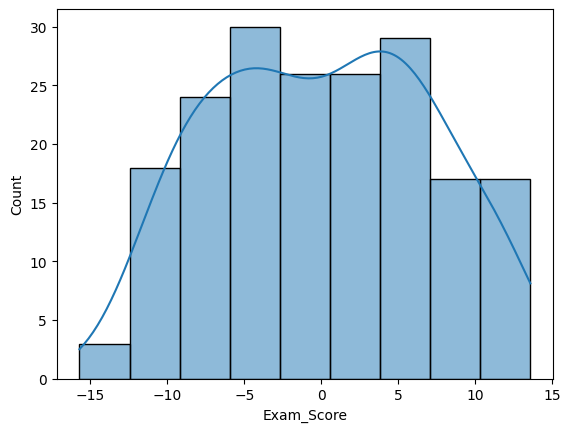

In [79]:
sns.histplot(df['Exam_Score'],kde=True)
plt.show()

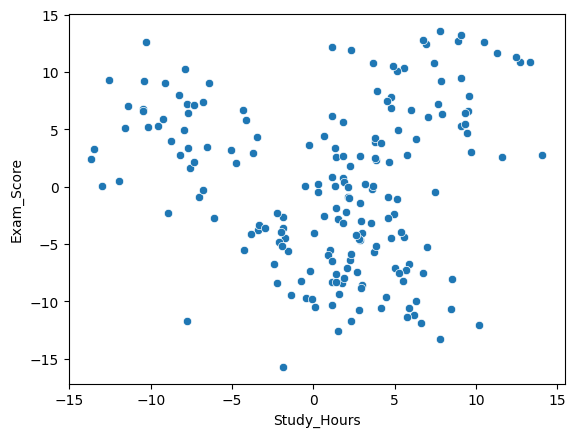

In [80]:
sns.scatterplot(x=df['Study_Hours'], y=df['Exam_Score'])
plt.show()